# Лабораторная работа №1 «Анализ и прогнозирование временных рядов на примере розничных продаж»

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
import numpy as np
import pywt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.diagnostic import het_breuschpagan
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf
import statsmodels.api as sm

Загрузка данных

In [50]:
file_path = 'retail_sales_mock_data.csv'
data = pd.read_csv(file_path, parse_dates=['Date'], index_col='Date')

data

,SalesAmount,Promotion,HolidayMonth
Date,,,
2020-01-01,12248,0,0
2020-02-01,13011,0,0
2020-03-01,12722,0,0
2020-04-01,14030,1,0
2020-05-01,7783,0,0
2020-06-01,9131,1,0
2020-07-01,9089,0,0
2020-08-01,10300,0,0
2020-09-01,10464,0,0


# Разведочный анализ данных (EDA)

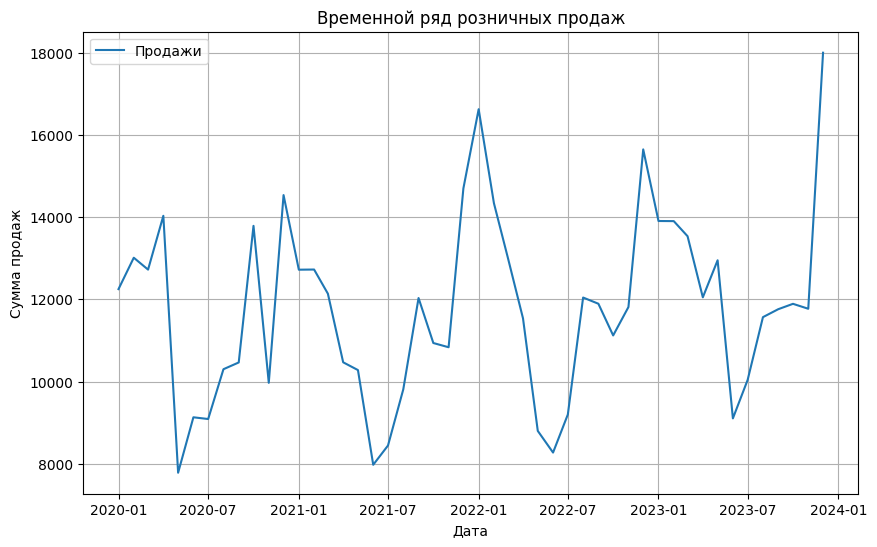

In [51]:
# Визуализация временного ряда продаж
plt.figure(figsize=(10, 6))
plt.plot(data['SalesAmount'], label='Продажи')
plt.title('Временной ряд розничных продаж')
plt.xlabel('Дата')
plt.ylabel('Сумма продаж')
plt.grid(True)
plt.legend()
plt.show()


График показывает зависимость продаж от времени. Видно, что временной ряд имеет явную сезонную зависимость и тренд

# Декомпозиция временного ряда

# аддитивная декомпозиция

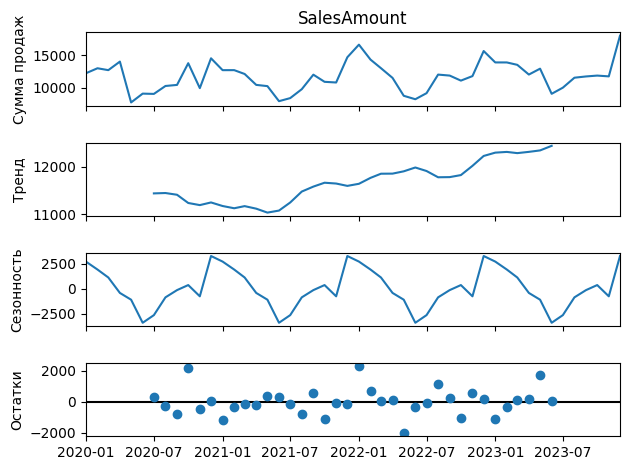

In [52]:

decomposition = seasonal_decompose(data['SalesAmount'], model='additive', period=12)

fig = decomposition.plot()
plt.subplots_adjust(hspace=0.5) 


fig.axes[0].set_ylabel('Сумма продаж')  
fig.axes[1].set_ylabel('Тренд')
fig.axes[2].set_ylabel('Сезонность')  
fig.axes[3].set_ylabel('Остатки')  

plt.show()


Видно, что тренд сначала шел на спад, потом имел постепенное увеличение, а сезонность — повторяющиеся колебания в пределах года. Остатки представляют собой случайные отклонения

# Спектральный анализ с использованием FFT

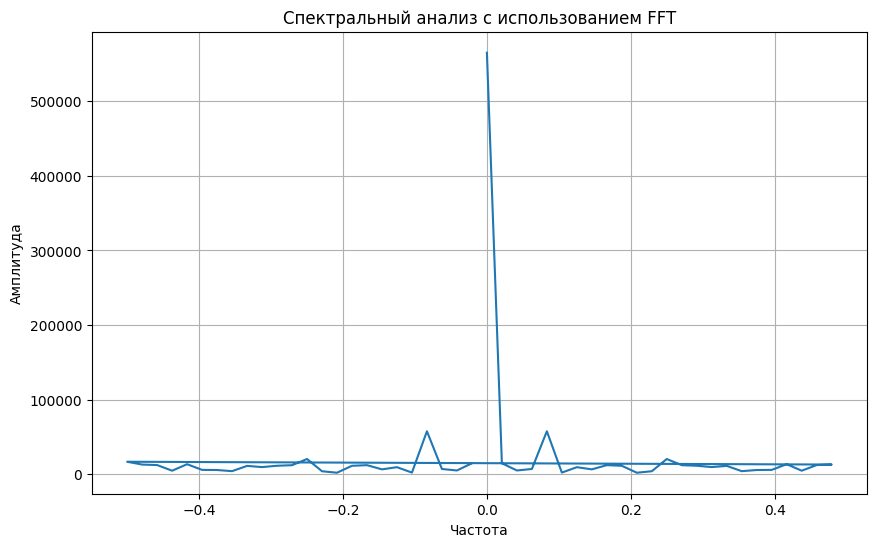

In [53]:
fft_result = np.fft.fft(data['SalesAmount'].values)
fft_freq = np.fft.fftfreq(len(data), d=1)

plt.figure(figsize=(10, 6))
plt.plot(fft_freq, np.abs(fft_result))
plt.title('Спектральный анализ с использованием FFT')
plt.xlabel('Частота')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.show()


Спектральный анализ показывает, что в ряду есть частотные компоненты, что свидетельствует о наличии периодичности в данных.

# Вейвлет-анализ

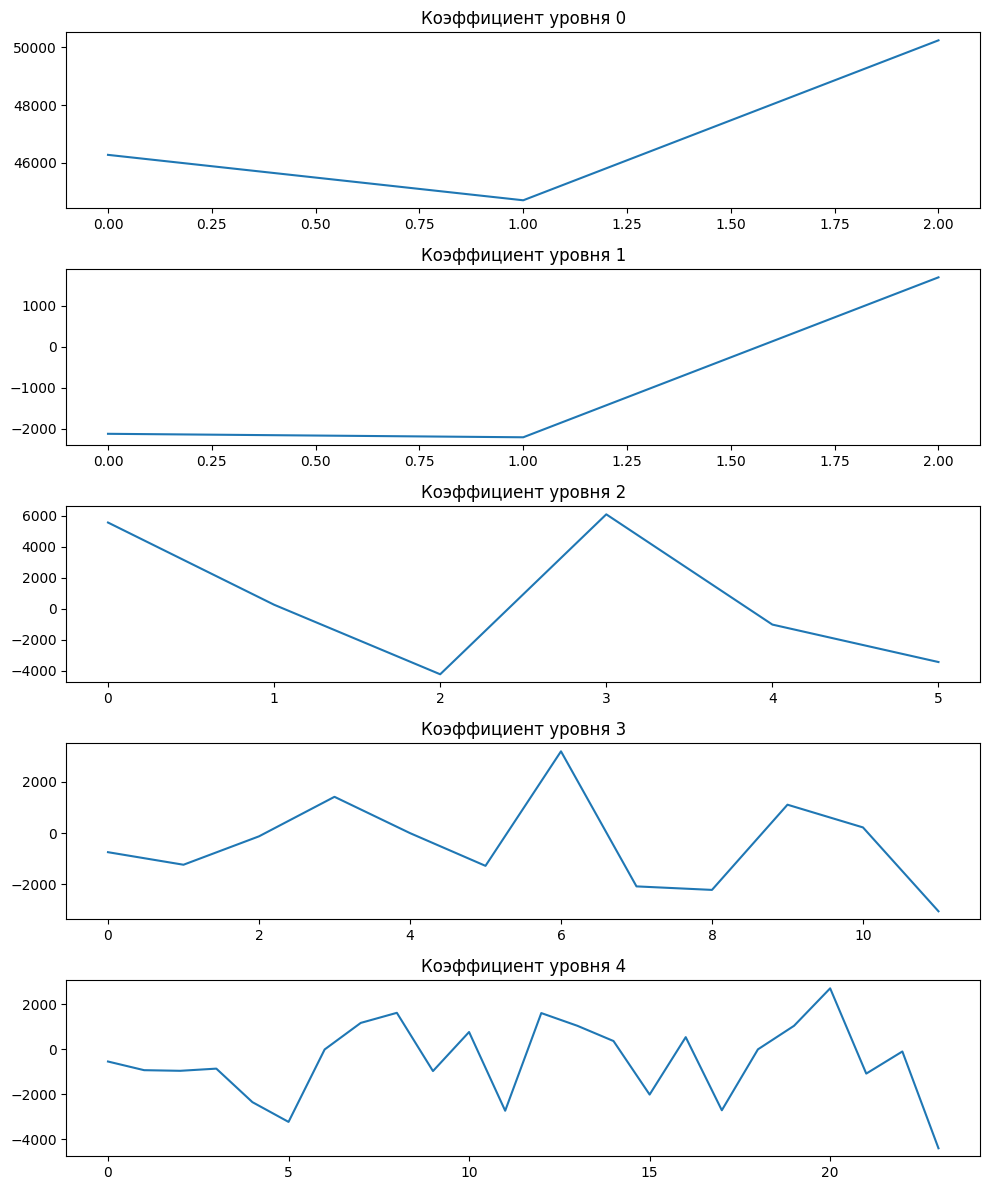

In [54]:
coeffs = pywt.wavedec(data['SalesAmount'], 'db1', level=4)

fig, axes = plt.subplots(5, 1, figsize=(10, 12))
for i, coeff in enumerate(coeffs):
    axes[i].plot(coeff)
    axes[i].set_title(f'Коэффициент уровня {i}')
plt.tight_layout()
plt.show()


Вейвлет-анализ позволяет выделить различные уровни частотных компонент. Каждый уровень представляет собой определенный аспект колебаний временного ряда. Этот метод позволяет глубже понять сложные сезонные и трендовые компоненты, которые трудно выявить другими методами.

ИТОГ
* Классическая аддитивная декомпозиция:

Результаты: Этот метод позволяет выделить тренд и сезонность в данных, при этом остатки представляют собой случайные колебания, что подтверждает правильность выделения тренда и сезонности.

Преимущества: Простота и наглядность. Аддитивная декомпозиция хорошо подходит для рядов с регулярной сезонностью и линейным трендом. Легко интерпретируемые компоненты.

Ограничения: Неэффективен для сложных временных рядов с переменной сезонностью или мультипликативным характером колебаний, где амплитуда сезонных колебаний зависит от уровня тренда.

* Спектральный анализ (FFT):

Результаты: Спектральный анализ выявил явное доминирование низкой частоты в данных, что позволяет сделать вывод о том, что периодические колебания отсутствуют, кроме как в виде тренда.

Преимущества: Хорош для выявления частотных компонентов и цикличности. Особенно полезен, когда важно увидеть, на каких частотах происходят колебания в данных.

Ограничения: Метод не всегда дает точные результаты для данных с переменной сезонностью или трендом. FFT требует, чтобы данные имели регулярную и фиксированную частотную составляющую.

* Вейвлет-анализ:

Результаты: Вейвлет-анализ позволил выделить различные уровни частотных компонент, от высокочастотных до низкочастотных. Это особенно полезно для более глубокого анализа и понимания структуры временного ряда.

Преимущества: Подходит для сложных временных рядов с переменной сезонностью и трендом. Вейвлет-анализ позволяет выделить как короткосрочные, так и долгосрочные компоненты, что делает его полезным для более сложных анализов.

Ограничения: Более сложный в интерпретации и требующий больше вычислительных ресурсов по сравнению с другими методами. 

# Построение прогнозных моделей

* Модель ARIMA

Разделение данных 

In [55]:
train_size = int(len(data) * 0.8)
train, test = data['SalesAmount'][:train_size], data['SalesAmount'][train_size:]

Обучение модели 

In [56]:
model_arima = ARIMA(train, order=(12, 1, 4))  # Параметры ARIMA (12, 1, 4)
model_arima_fit = model_arima.fit()

C:\Users\nkv17\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\nkv17\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\nkv17\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\nkv17\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\Local

Прогнозирование

In [57]:
forecast_arima = model_arima_fit.forecast(steps=12)

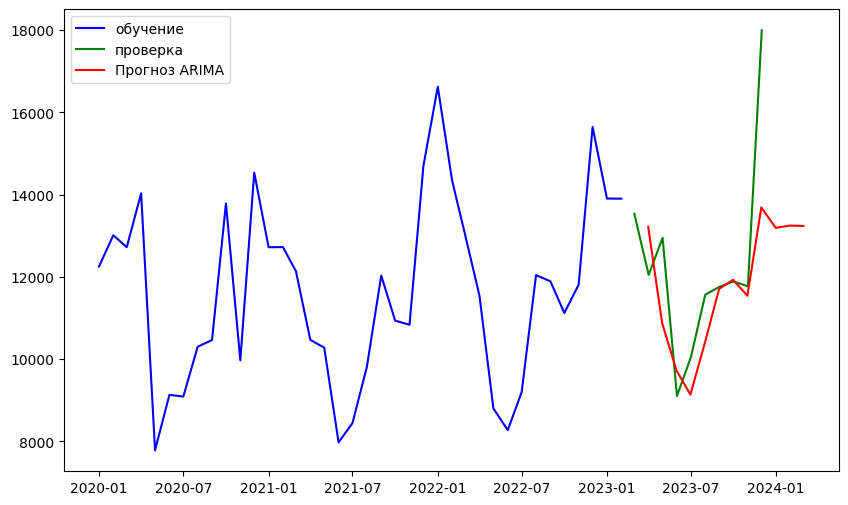

In [58]:
plt.figure(figsize=(10, 6))
plt.plot(data.index[:train_size], train, label='обучение', color='blue')
plt.plot(data.index[train_size:], test, label='проверка', color='green')
plt.plot(pd.date_range(data.index[train_size], periods=12, freq='ME'), forecast_arima, label='Прогноз ARIMA', color='red')
plt.legend()
plt.show()

* Модель SARIMAX

Разделение данных 

In [59]:
train_size = int(len(data) * 0.8)
train, test = data['SalesAmount'][:train_size], data['SalesAmount'][train_size:]

Обучение модели

sarimax_model = SARIMAX(train, order=(2, 1, 2), seasonal_order=(2, 1, 2, 12))
sarimax_model_fit = sarimax_model.fit()

Прогнозирование

In [60]:
forecast_sarimax = sarimax_model_fit.forecast(steps=12)

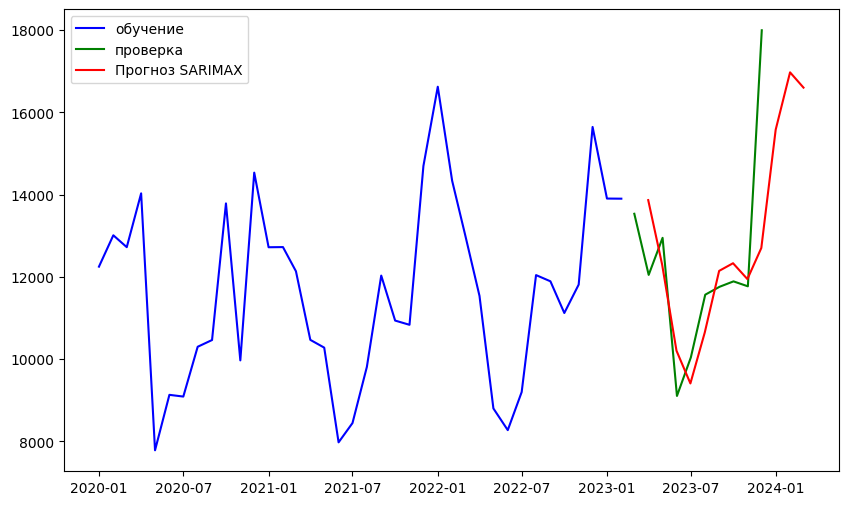

In [61]:
plt.figure(figsize=(10, 6))
plt.plot(data.index[:train_size], train, label='обучение', color='blue')
plt.plot(data.index[train_size:], test, label='проверка', color='green')
plt.plot(pd.date_range(data.index[train_size], periods=12, freq='ME'), forecast_sarimax, label='Прогноз SARIMAX', color='red')
plt.legend()
plt.show()

# Оценка качества моделей

MSE и R² для ARIMA

In [62]:
mse_arima = mean_squared_error(data['SalesAmount'][-12:], forecast_arima)
r2_arima = r2_score(data['SalesAmount'][-12:], forecast_arima)
print(f"ARIMA MSE: {mse_arima}, ARIMA R²: {r2_arima}")

ARIMA MSE: 6646229.013396147, ARIMA R²: -0.43706788217129455


MSE и R² для SARIMAX

In [63]:
mse_sarimax = mean_squared_error(data['SalesAmount'][-12:], forecast_sarimax)
r2_sarimax = r2_score(data['SalesAmount'][-12:], forecast_sarimax)
print(f"SARIMAX MSE: {mse_sarimax}, SARIMAX R²: {r2_sarimax}")

SARIMAX MSE: 7005415.943333504, SARIMAX R²: -0.5147323742717449


In [64]:
print(f"ARIMA AIC: {model_arima_fit.aic}, ARIMA BIC: {model_arima_fit.bic}")


print(f"SARIMAX AIC: {sarimax_model_fit.aic}, SARIMAX BIC: {sarimax_model_fit.bic}")


ARIMA AIC: 687.8068818105646, ARIMA BIC: 715.1924863255165
SARIMAX AIC: 460.0316426744324, SARIMAX BIC: 471.00152509824625


* ARIMA

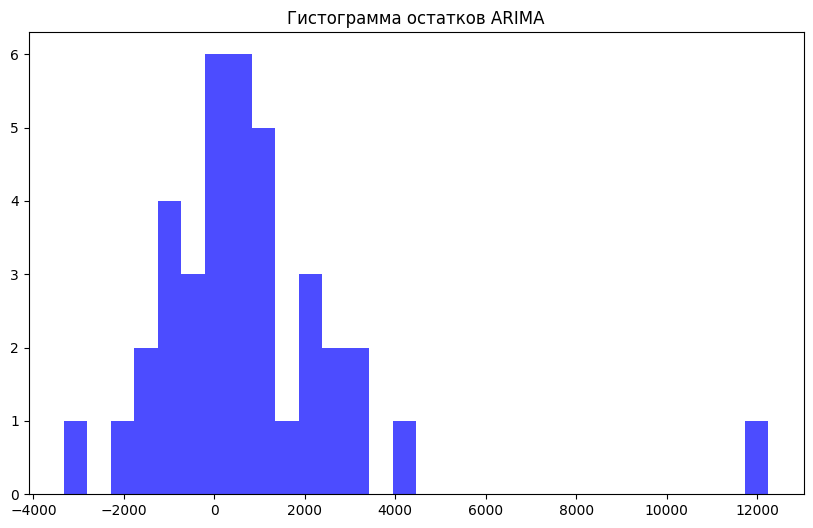

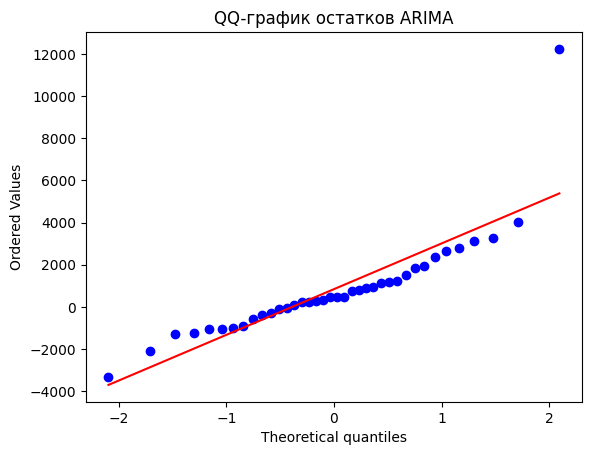

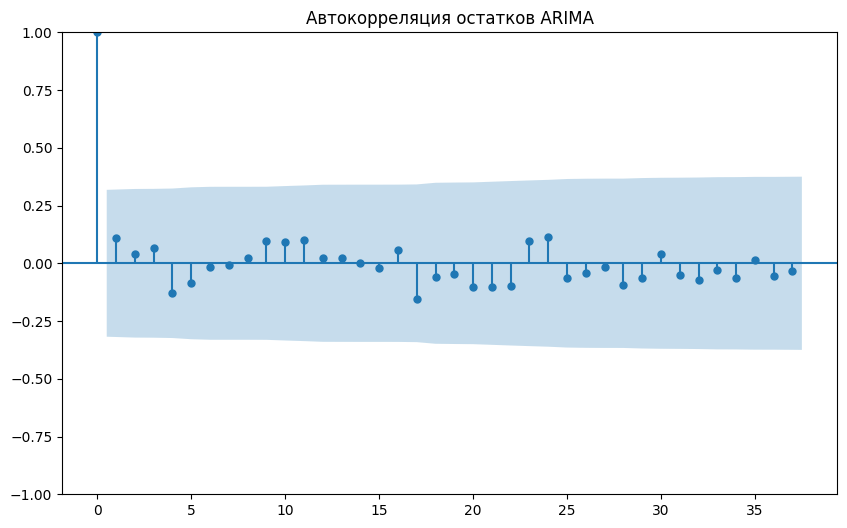

p-значение теста Бреуша-Пагана: 5.123442924421037e-07


In [65]:
residuals_arima = model_arima_fit.resid

# Проверка нормальности
plt.figure(figsize=(10, 6))
plt.hist(residuals_arima, bins=30, alpha=0.7, color='blue')
plt.title('Гистограмма остатков ARIMA')
plt.show()

# QQ-график
stats.probplot(residuals_arima, dist="norm", plot=plt)
plt.title('QQ-график остатков ARIMA')
plt.show()

# Автокорреляция
plt.figure(figsize=(10, 6))
plot_acf(residuals_arima, lags=37, ax=plt.gca(), title="Автокорреляция остатков ARIMA")
plt.show()

#Константа для теста
const = sm.add_constant(residuals_arima)

# Тест на гомоскедастичность
bp_test_arima = het_breuschpagan(residuals_arima, const)
print("p-значение теста Бреуша-Пагана:", bp_test_arima[1])



* SARIMAX

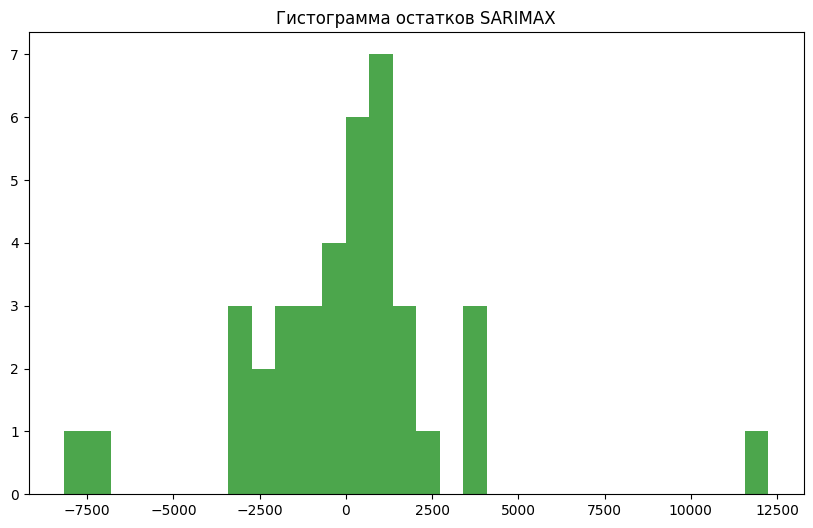

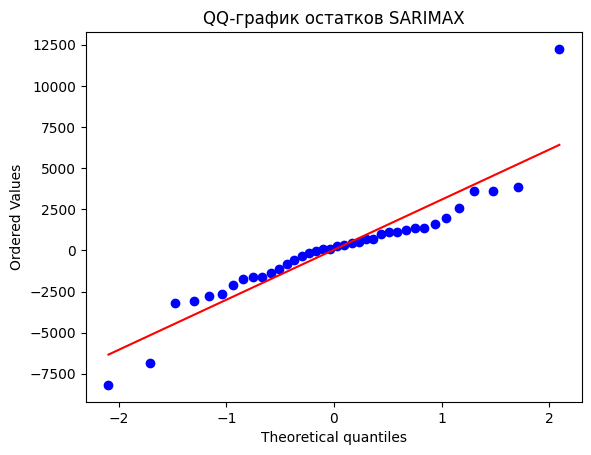

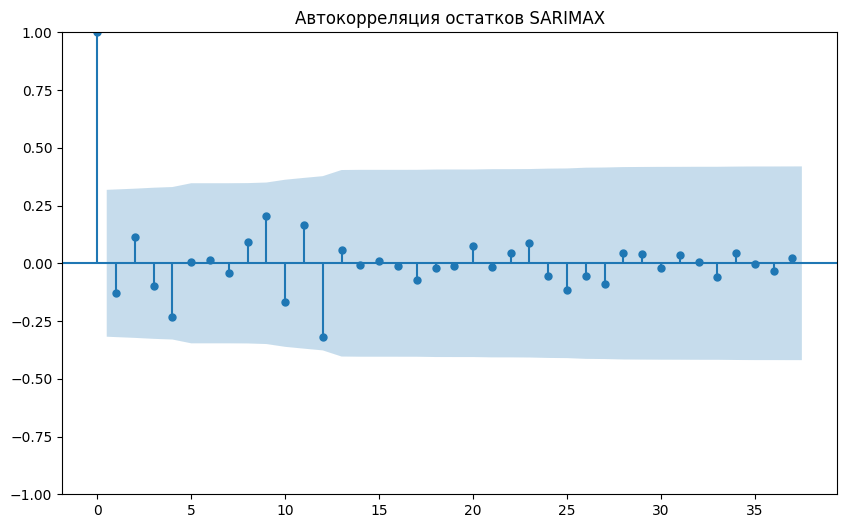

p-значение теста Бреуша-Пагана 0.046931649203682826


In [66]:
residuals_sarimax = sarimax_model_fit.resid

# Проверка нормальности
plt.figure(figsize=(10, 6))
plt.hist(residuals_sarimax, bins=30, alpha=0.7, color='green')
plt.title('Гистограмма остатков SARIMAX')
plt.show()

# QQ-график
stats.probplot(residuals_sarimax, dist="norm", plot=plt)
plt.title('QQ-график остатков SARIMAX')
plt.show()

# Автокорреляция
plt.figure(figsize=(10, 6))
plot_acf(residuals_sarimax, lags=37, ax=plt.gca(), title="Автокорреляция остатков SARIMAX")
plt.show()

const = sm.add_constant(residuals_sarimax)

# Тест на гомоскедастичность
bp_test_sarimax = het_breuschpagan(residuals_sarimax, const)
print("p-значение теста Бреуша-Пагана", bp_test_sarimax[1])


In [67]:
if model_arima_fit.aic < sarimax_model_fit.aic:
    print("ARIMA лучше по AIC")
else:
    print("SARIMAX лучше по AIC")

if model_arima_fit.bic < sarimax_model_fit.bic:
    print("ARIMA лучше по BIC")
else:
    print("SARIMAX лучше по BIC")

if bp_test_arima[1] < 0.05:
    print("Остатки ARIMA показывают гетероскедастичность")
else:
    print("Остатки ARIMA не показывают гетероскедастичность")

if bp_test_sarimax[1] < 0.05:
    print("Остатки SARIMAX показывают гетероскедастичность")
else:
    print("Остатки SARIMAX не показывают гетероскедастичность")

SARIMAX лучше по AIC
SARIMAX лучше по BIC
Остатки ARIMA показывают гетероскедастичность
Остатки SARIMAX показывают гетероскедастичность


SARIMAX оказалась предпочтительнее ARIMA по большинству метрик. Она дала более точные прогнозы и продемонстрировала лучшие результаты по информационным критериям. Это делает ее более предпочтительным выбором для анализа и прогнозирования данных с сезонными колебаниями.Выбор между моделями зависит от специфики данных.